# Regression & Spatial Regression

**Author:** Alexander Michels

This notebook walks through the basics of regression in Python.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

## Loading Our Data

In [2]:
import libpysal
from libpysal.examples import load_example
from libpysal.weights import Queen
from spreg import ML_Error_Regimes
import geopandas as gpd
from spreg import ML_Lag, ML_Error

Pysal example datasets: https://pysal.org/notebooks/lib/libpysal/Example_Datasets.html

In [3]:
gdf = gpd.read_file(load_example('Guerry').get_path("guerry.shp"))
gdf.head()

,dept,Region,Dprtmnt,Crm_prs,Crm_prp,Litercy,Donatns,Infants,Suicids,MainCty,...,Infntcd,Dntn_cl,Lottery,Desertn,Instrct,Prsttts,Distanc,Area,Pop1831,geometry
0,1.0,E,Ain,28870.0,15890.0,37.0,5098.0,33120.0,35039.0,2.0,...,60.0,69.0,41.0,55.0,46.0,13.0,218.372,5762.0,346.03,"POLYGON ((801150.000 2092615.000, 800669.000 2..."
1,2.0,N,Aisne,26226.0,5521.0,51.0,8901.0,14572.0,12831.0,2.0,...,82.0,36.0,38.0,82.0,24.0,327.0,65.945,7369.0,513.00,"POLYGON ((729326.000 2521619.000, 729320.000 2..."
2,3.0,C,Allier,26747.0,7925.0,13.0,10973.0,17044.0,114121.0,2.0,...,42.0,76.0,66.0,16.0,85.0,34.0,161.927,7340.0,298.26,"POLYGON ((710830.000 2137350.000, 711746.000 2..."
3,4.0,E,Basses-Alpes,12935.0,7289.0,46.0,2733.0,23018.0,14238.0,1.0,...,12.0,37.0,80.0,32.0,29.0,2.0,351.399,6925.0,155.90,"POLYGON ((882701.000 1920024.000, 882408.000 1..."
4,5.0,E,Hautes-Alpes,17488.0,8174.0,69.0,6962.0,23076.0,16171.0,1.0,...,23.0,64.0,79.0,35.0,7.0,1.0,320.280,5549.0,129.10,"POLYGON ((886504.000 1922890.000, 885733.000 1..."


In [4]:
x_var = "Wealth"
y_var = "Litercy"

<Axes: >

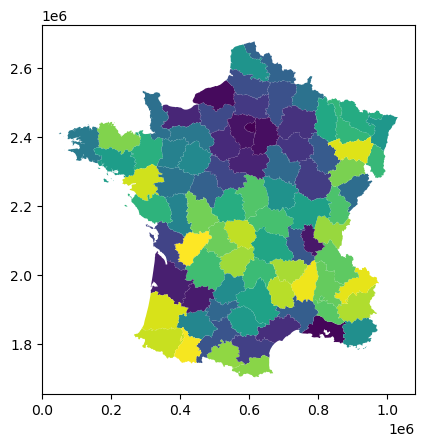

In [5]:
gdf.plot(x_var)

<Axes: >

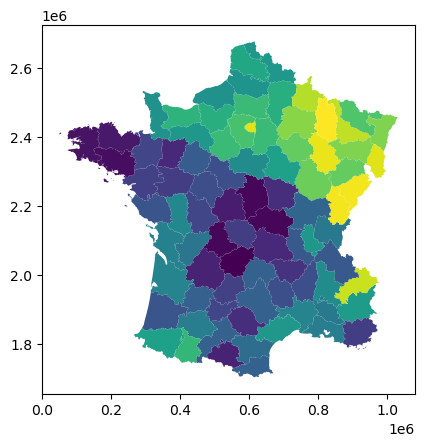

In [6]:
gdf.plot(y_var)

## Aspatial Regression

We will use the Guerry dataset from statsmodels, more info here: https://vincentarelbundock.github.io/Rdatasets/doc/HistData/Guerry.html 

Using the Guerry example data from `statsmodels`, let's fit an Ordinary Least Squares (OLS) Linear Regression model. Documentation here: https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.OLS.html

In [7]:
x = np.asarray(gdf[x_var]).T
x.shape = (len(x), 1)  # treat it as a 2 dimensional array, required for pysal
y = np.asarray(gdf[y_var]).T
y.shape = (len(y), 1)  # treat it as a 2 dimensional array, required for pysal

In [8]:
X = sm.add_constant(x)  # add a constant that allows forn intercept
model = sm.OLS(y, X)  # create the Ordinary Least Squared regression between Y and X
results = model.fit()  # fit the model to determine the parameters
results.summary()  # print out all of the results from our model

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     6.775
Date:                Wed, 08 Oct 2025   Prob (F-statistic):             0.0110
Time:                        16:44:08   Log-Likelihood:                -359.74
No. Observations:                  85   AIC:                             723.5
Df Residuals:                      83   BIC:                             728.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         47.4532      3.680     12.894      0.000      40.133      54.773
x1            -0.1907      0.073     -2.603      0.011      -0.337      -0.045
==============================================================================
Omnibus:                        6.346   Durbin-Watson:                   2.045
Prob(Omnibus):                  0.042   Jarque-Bera (JB):                6.105
Skew:                           0.600   Prob(JB):                       0.0472
Kurtosis:                       2.466   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
import seaborn as sns

<Axes: xlabel='Wealth', ylabel='Litercy'>

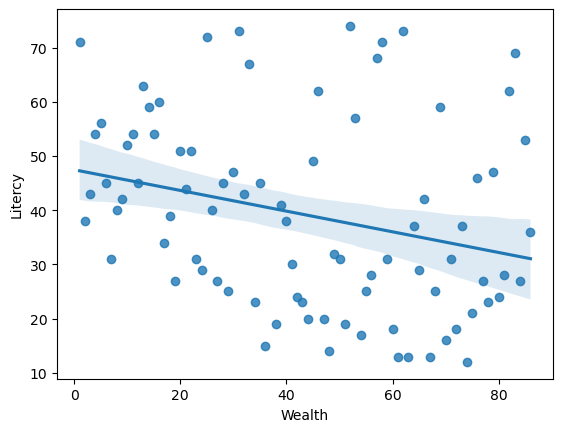

In [10]:
sns.regplot(x=x_var , y=y_var, data=gdf)  # seaborn can plot our regression with a confidence interval

## Spatial Regression

Now we will use the `pysal` ecosystem of libraries and specifically spreg (spatial regression) to calculate spatial regressions.

Now we can calculate the Queen weight matrix from our GeoDataFrame:

In [11]:
w = Queen.from_dataframe(gdf)
w.transform = 'r'  # normalize by rows so weights for each spatial unit adds up to 1

The documentation for the Maximum Likelihood estimation of the Spatial Lag Model is here: https://pysal.org/spreg/generated/spreg.ML_Lag.html

In [12]:
mllag = ML_Lag(y, x, w)

/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.9.4/lib/python3.8/site-packages/scipy/optimize/_minimize.py:892: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  warn("Method 'bounded' does not support relative tolerance in x; "


In [13]:
mllag.rho

0.865300666584274

In [14]:
print(mllag.summary)

REGRESSION
----------
SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :     dep_var                Number of Observations:          85
Mean dependent var  :     39.1412                Number of Variables   :           3
S.D. dependent var  :     17.4343                Degrees of Freedom    :          82
Pseudo R-squared    :      0.7745
Spatial Pseudo R-squared:  0.1378
Sigma-square ML     :      73.472                Log likelihood        :    -314.057
S.E of regression   :       8.572                Akaike info criterion :     634.113
                                                 Schwarz criterion     :     641.441

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----------------------------

The documentation for the Maximum Likelihood estimation of the Spatial Error Model is here: https://spreg.readthedocs.io/en/latest/generated/spreg.ML_Error.html

In [15]:
mlerror = ML_Error(y, x, w)

In [16]:
mlerror.lam

0.8806036164579609

In [17]:
print(mlerror.summary)

REGRESSION
----------
SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL ERROR (METHOD = FULL)
-------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :     dep_var                Number of Observations:          85
Mean dependent var  :     39.1412                Number of Variables   :           2
S.D. dependent var  :     17.4343                Degrees of Freedom    :          83
Pseudo R-squared    :      0.0755
Sigma-square ML     :      70.875                Log likelihood        :    -313.183
S.E of regression   :       8.419                Akaike info criterion :     630.366
                                                 Schwarz criterion     :     635.251

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----------------------------------------------------------